# Analyze Models

Load saved model artifacts, rebuild metrics, and generate diagnostics plus feature-importance plots.

Run `02_train_and_compare.ipynb` first when artifacts are missing or stale.


In [9]:
from pathlib import Path
import json
import sys
import warnings
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
from IPython.display import display
from joblib import dump, load
from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import permutation_importance


def ensure_project_root() -> Path:
    """Put repo root on sys.path for local imports in notebooks."""
    cwd = Path.cwd().resolve()
    for root in (cwd, *cwd.parents):
        if (root / "pricing_lab" / "__init__.py").is_file():
            root_str = str(root)
            if root_str not in sys.path:
                sys.path.insert(0, root_str)
            return root
    raise RuntimeError("Could not find project root containing pricing_lab.")


PROJECT_ROOT = ensure_project_root()

from pricing_lab import config
from pricing_lab.data import TrainTestData, load_train_test
from pricing_lab.metrics import compute_dollar_metrics
from pricing_lab.models.elastic_net import tune_elastic_net
from pricing_lab.models.ensemble import (
    fit_equal_voting_ensemble,
    fit_stacking_ensemble,
    fit_weighted_voting_ensemble,
    select_ensemble_candidates,
)
from pricing_lab.models.knn import tune_knn
from pricing_lab.models.neural_network import tune_neural_network
from pricing_lab.models.random_forest import tune_random_forest
from pricing_lab.models.svm import tune_svm
from pricing_lab.models.xgboost_model import tune_xgboost

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)

Project root: /Users/Kushal/Projects/BNB_Pricing
Python: /opt/homebrew/Caskroom/miniforge/base/envs/ml-optimized/bin/python


In [10]:
# Analysis controls
CSV_PATH = None
MODE = "sample"  # sample | full
RUN_TRAINING = False

# Used only if you intentionally retrain from this notebook.
N_TRIALS_ELASTIC = None
N_TRIALS_KNN = None
N_TRIALS_XGB = None
N_TRIALS_RANDOM_FOREST = None
N_TRIALS_SVM = None
N_TRIALS_NEURAL_NETWORK = None
N_TRIALS_WEIGHTED_ENSEMBLE = None

# Sample mode keeps analysis iteration fast.
SAMPLE_TRAIN_FRACTION = 0.35

# Artifact and plot outputs
MODEL_OUTPUT_DIR = "artifacts"
SAVE_MODELS = True
OUTPUT_CSV = None
PLOTS_OUTPUT_DIR = "artifacts/plots"
SAVE_PLOTS = False

# Leave these False for artifact-only analysis.
RETRAIN_ELASTICNET = False
RETRAIN_KNN = False
RETRAIN_XGBOOST = False
RETRAIN_RANDOM_FOREST = False
RETRAIN_SVM = False
RETRAIN_NEURAL_NETWORK = False
RETRAIN_VOTING_EQUAL = False
RETRAIN_VOTING_WEIGHTED = False
RETRAIN_STACKING = False

# Runtime-heavy analysis toggles
SCATTER_SAMPLE_SIZE = 3000
RUN_PERMUTATION = False
RUN_SHAP = True
SHAP_SAMPLE_SIZE = 300
SHAP_BACKGROUND_SIZE = 80
TOP_FEATURE_COUNT = 21
PERMUTATION_REPEATS = 1

In [11]:
# Rebuild the same test split used for evaluation.
resolved_csv = config.DATA_PATH if CSV_PATH is None else Path(CSV_PATH)
print("Using CSV:", resolved_csv)

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

full_data: TrainTestData = load_train_test(csv_path=str(CSV_PATH) if CSV_PATH is not None else None)
print(f"Mode: {MODE}")
print(f"Train rows: {len(full_data.X_train)}, test rows: {len(full_data.X_test)}")

if MODE not in {"sample", "full"}:
    raise ValueError("MODE must be 'sample' or 'full'.")

if MODE == "sample":
    sampled_features = full_data.X_train.sample(frac=SAMPLE_TRAIN_FRACTION, random_state=config.RANDOM_STATE)
    sampled_target = full_data.y_train.loc[sampled_features.index]
    data = TrainTestData(
        X_train=sampled_features.reset_index(drop=True),
        X_test=full_data.X_test,
        y_train=sampled_target.reset_index(drop=True),
        y_test=full_data.y_test,
    )
    print(
        f"Sample mode: using {len(data.X_train)} / {len(full_data.X_train)} train rows "
        f"({SAMPLE_TRAIN_FRACTION:.0%}) for Optuna + fit."
    )
else:
    data = full_data

Using CSV: /Users/Kushal/Projects/BNB_Pricing/AB_NYC_2019.csv
Mode: sample
Train rows: 36700, test rows: 9176
Sample mode: using 12845 / 36700 train rows (35%) for Optuna + fit.


In [12]:
# Load artifacts by default; retraining here is only a recovery path.
SAMPLE_TRIALS = {
    "elastic_net": 10,
    "knn": 6,
    "xgboost": 14,
    "random_forest": 10,
    "svm": 8,
    "neural_network": 12,
    "weighted_ensemble": 8,
}
FULL_TRIALS = {
    "elastic_net": config.N_TRIALS_ELASTICNET,
    "knn": config.N_TRIALS_KNN,
    "xgboost": config.N_TRIALS_XGBOOST,
    "random_forest": config.N_TRIALS_RANDOM_FOREST,
    "svm": config.N_TRIALS_SVM,
    "neural_network": config.N_TRIALS_NEURAL_NETWORK,
    "weighted_ensemble": 20,
}
trial_overrides = {
    "elastic_net": N_TRIALS_ELASTIC,
    "knn": N_TRIALS_KNN,
    "xgboost": N_TRIALS_XGB,
    "random_forest": N_TRIALS_RANDOM_FOREST,
    "svm": N_TRIALS_SVM,
    "neural_network": N_TRIALS_NEURAL_NETWORK,
    "weighted_ensemble": N_TRIALS_WEIGHTED_ENSEMBLE,
}


def resolve_trials(key: str) -> int:
    override = trial_overrides[key]
    if override is not None:
        return int(override)
    defaults = SAMPLE_TRIALS if MODE == "sample" else FULL_TRIALS
    return int(defaults[key])


model_output_path = PROJECT_ROOT / MODEL_OUTPUT_DIR
model_output_path.mkdir(parents=True, exist_ok=True)

base_specs = [
    ("ElasticNet", "elastic_net.joblib", RETRAIN_ELASTICNET, lambda: tune_elastic_net(data, n_trials=resolve_trials("elastic_net"))),
    ("KNN", "knn.joblib", RETRAIN_KNN, lambda: tune_knn(data, n_trials=resolve_trials("knn"))),
    ("XGBoost", "xgboost.joblib", RETRAIN_XGBOOST, lambda: tune_xgboost(data, n_trials=resolve_trials("xgboost"))),
    ("RandomForest", "random_forest.joblib", RETRAIN_RANDOM_FOREST, lambda: tune_random_forest(data, n_trials=resolve_trials("random_forest"))),
    ("SVM", "svm.joblib", RETRAIN_SVM, lambda: tune_svm(data, n_trials=resolve_trials("svm"))),
    ("NeuralNetwork", "neural_network.joblib", RETRAIN_NEURAL_NETWORK, lambda: tune_neural_network(data, n_trials=resolve_trials("neural_network"))),
]

model_pipelines: dict[str, Any] = {}
metrics_map: dict[str, dict[str, Any]] = {}

for model_name, artifact_name, retrain_flag, train_fn in base_specs:
    artifact_path = model_output_path / artifact_name
    should_retrain = RUN_TRAINING and retrain_flag
    if should_retrain:
        print(f"Training {model_name}...")
        result = train_fn()
        model_pipelines[model_name] = result.pipeline
        metrics_map[model_name] = {
            "name": result.name,
            "cv_rmse_log": float(result.best_cv_rmse_log),
            "test_metrics": result.test_metrics,
            "best_params": result.best_params,
        }
        if SAVE_MODELS:
            dump(result.pipeline, artifact_path)
            print(f"Wrote {artifact_path}")
        continue
    if not artifact_path.exists():
        raise FileNotFoundError(f"Missing artifact for {model_name}: {artifact_path}. Enable RETRAIN flag or RUN_TRAINING.")
    model_pipelines[model_name] = load(artifact_path)


y_true_dollars = np.expm1(data.y_test.to_numpy(dtype=np.float64))


def evaluate_pipeline(model_name: str, pipeline: Any) -> dict[str, Any]:
    y_pred_log = np.asarray(pipeline.predict(data.X_test), dtype=np.float64)
    test_metrics = compute_dollar_metrics(data.y_test.to_numpy(dtype=np.float64), y_pred_log)
    return {
        "name": model_name,
        "cv_rmse_log": float("nan"),
        "test_metrics": test_metrics,
        "best_params": {"source": "loaded_artifact"},
    }


for model_name, _, _, _ in base_specs:
    if model_name not in metrics_map:
        metrics_map[model_name] = evaluate_pipeline(model_name, model_pipelines[model_name])

base_selection_scores: dict[str, float] = {}
for model_name in [spec[0] for spec in base_specs]:
    cv_score = float(metrics_map[model_name]["cv_rmse_log"])
    if np.isfinite(cv_score):
        base_selection_scores[model_name] = cv_score
    else:
        base_selection_scores[model_name] = float(metrics_map[model_name]["test_metrics"]["rmse"])

selected_base = select_ensemble_candidates(
    {name: model_pipelines[name] for name in base_selection_scores},
    base_selection_scores,
)
print(f"Ensemble candidates: {', '.join(selected_base.keys())}")

ensemble_specs = [
    ("VotingEnsembleEqual", "voting_equal.joblib", RETRAIN_VOTING_EQUAL),
    ("VotingEnsembleWeighted", "voting_weighted.joblib", RETRAIN_VOTING_WEIGHTED),
    ("StackingEnsemble", "stacking.joblib", RETRAIN_STACKING),
]

for ensemble_name, artifact_name, retrain_flag in ensemble_specs:
    artifact_path = model_output_path / artifact_name
    should_retrain = RUN_TRAINING and retrain_flag
    if should_retrain:
        print(f"Training {ensemble_name}...")
        if ensemble_name == "VotingEnsembleEqual":
            result = fit_equal_voting_ensemble(data, selected_base)
        elif ensemble_name == "VotingEnsembleWeighted":
            result = fit_weighted_voting_ensemble(data, selected_base, n_trials=resolve_trials("weighted_ensemble"))
        else:
            result = fit_stacking_ensemble(data, selected_base)
        model_pipelines[ensemble_name] = result.pipeline
        metrics_map[ensemble_name] = {
            "name": result.name,
            "cv_rmse_log": float(result.best_cv_rmse_log),
            "test_metrics": result.test_metrics,
            "best_params": result.best_params,
        }
        if SAVE_MODELS:
            dump(result.pipeline, artifact_path)
            print(f"Wrote {artifact_path}")
        continue
    if not artifact_path.exists():
        raise FileNotFoundError(f"Missing artifact for {ensemble_name}: {artifact_path}. Enable RETRAIN flag or RUN_TRAINING.")
    loaded_pipeline = load(artifact_path)
    model_pipelines[ensemble_name] = loaded_pipeline
    metrics_map[ensemble_name] = evaluate_pipeline(ensemble_name, loaded_pipeline)


def validate_metric_payload(model_name: str, test_metrics: dict[str, float]) -> None:
    mae_value = float(test_metrics["mae"])
    rmse_value = float(test_metrics["rmse"])
    if rmse_value + 1e-12 < mae_value:
        raise ValueError(f"Invalid metrics for {model_name}: RMSE must be greater than or equal to MAE.")


def result_row(payload: dict[str, Any]) -> dict[str, Any]:
    cv_value = float(payload["cv_rmse_log"])
    cv_output = round(cv_value, 6) if np.isfinite(cv_value) else float("nan")
    model_name = str(payload["name"])
    test_metrics = payload["test_metrics"]
    validate_metric_payload(model_name, test_metrics)
    return {
        "model": model_name,
        "cv_rmse_log": cv_output,
        "test_mae_dollars": round(float(test_metrics["mae"]), 4),
        "test_rmse_dollars": round(float(test_metrics["rmse"]), 4),
        "test_r2": round(float(test_metrics["r2"]), 6),
        "best_params_json": json.dumps(payload["best_params"], sort_keys=True),
    }

rows = [result_row(metrics_map[name]) for name in model_pipelines.keys()]
table = pd.DataFrame(rows)
display(table)

if OUTPUT_CSV is not None:
    output_csv_path = PROJECT_ROOT / OUTPUT_CSV
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(output_csv_path, index=False)
    print(f"Wrote {output_csv_path}")

y_true_log = data.y_test.to_numpy(dtype=np.float64)
y_true_dollars = np.expm1(y_true_log)
predictions_log = {
    model_name: model_pipeline.predict(data.X_test)
    for model_name, model_pipeline in model_pipelines.items()
}
predictions_dollars = {
    model_name: np.expm1(np.asarray(prediction, dtype=np.float64))
    for model_name, prediction in predictions_log.items()
}
residuals = {
    model_name: y_true_dollars - prediction
    for model_name, prediction in predictions_dollars.items()
}
absolute_errors = {
    model_name: np.abs(values)
    for model_name, values in residuals.items()
}

rng = np.random.default_rng(config.RANDOM_STATE)
scatter_sample_size = min(SCATTER_SAMPLE_SIZE, len(y_true_dollars))
scatter_indices = rng.choice(len(y_true_dollars), size=scatter_sample_size, replace=False)

plot_dir = PROJECT_ROOT / PLOTS_OUTPUT_DIR
if SAVE_PLOTS:
    plot_dir.mkdir(parents=True, exist_ok=True)

/opt/homebrew/Caskroom/miniforge/base/envs/ml-optimized/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ml-optimized/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ml-optimized/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVe

Ensemble candidates: XGBoost, RandomForest


,model,cv_rmse_log,test_mae_dollars,test_rmse_dollars,test_r2,best_params_json
0,ElasticNet,NaN,32.9546,46.9603,0.513512,"{""source"": ""loaded_artifact""}"
1,KNN,NaN,31.6300,45.1741,0.549815,"{""source"": ""loaded_artifact""}"
2,XGBoost,NaN,30.1947,43.5573,0.581464,"{""source"": ""loaded_artifact""}"
3,RandomForest,NaN,31.1297,44.8469,0.556315,"{""source"": ""loaded_artifact""}"
4,SVM,NaN,32.3418,46.6294,0.520344,"{""source"": ""loaded_artifact""}"
5,NeuralNetwork,NaN,33.4921,48.0047,0.491632,"{""source"": ""loaded_artifact""}"
6,VotingEnsembleEqual,NaN,31.3115,45.2270,0.548760,"{""source"": ""loaded_artifact""}"
7,VotingEnsembleWeighted,NaN,31.0925,44.8686,0.555884,"{""source"": ""loaded_artifact""}"
8,StackingEnsemble,NaN,31.0884,44.7896,0.557446,"{""source"": ""loaded_artifact""}"


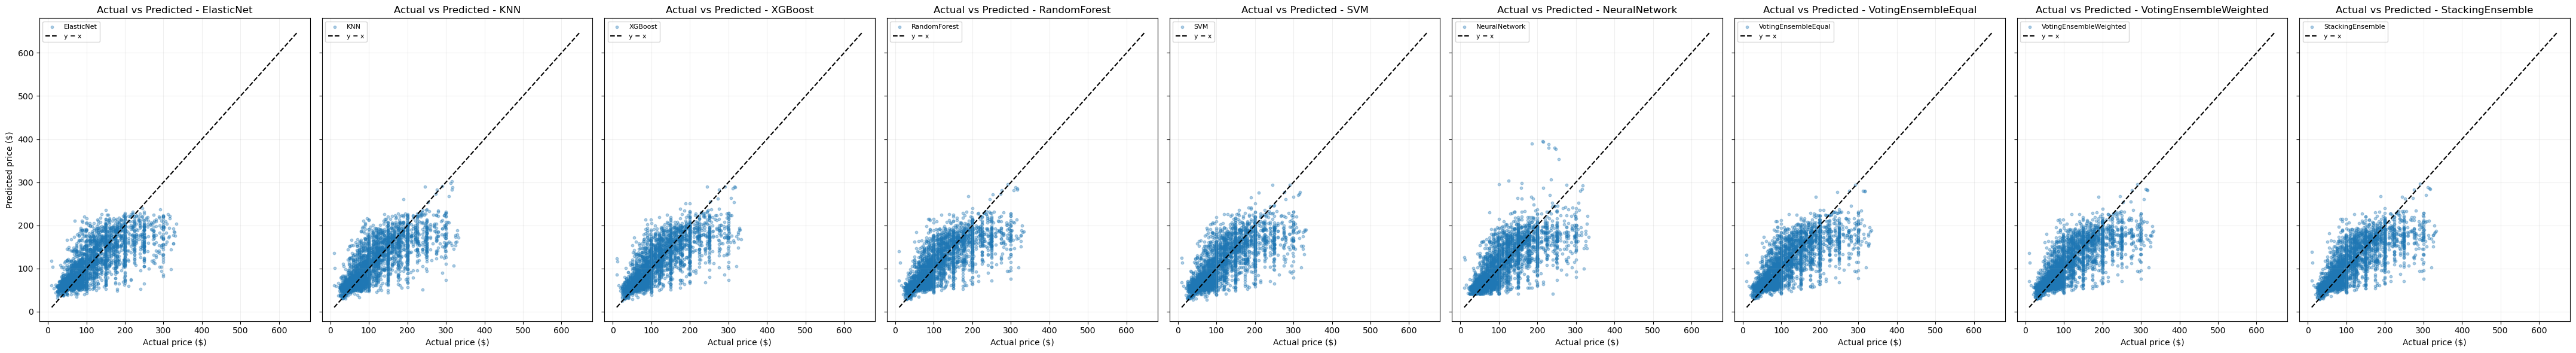

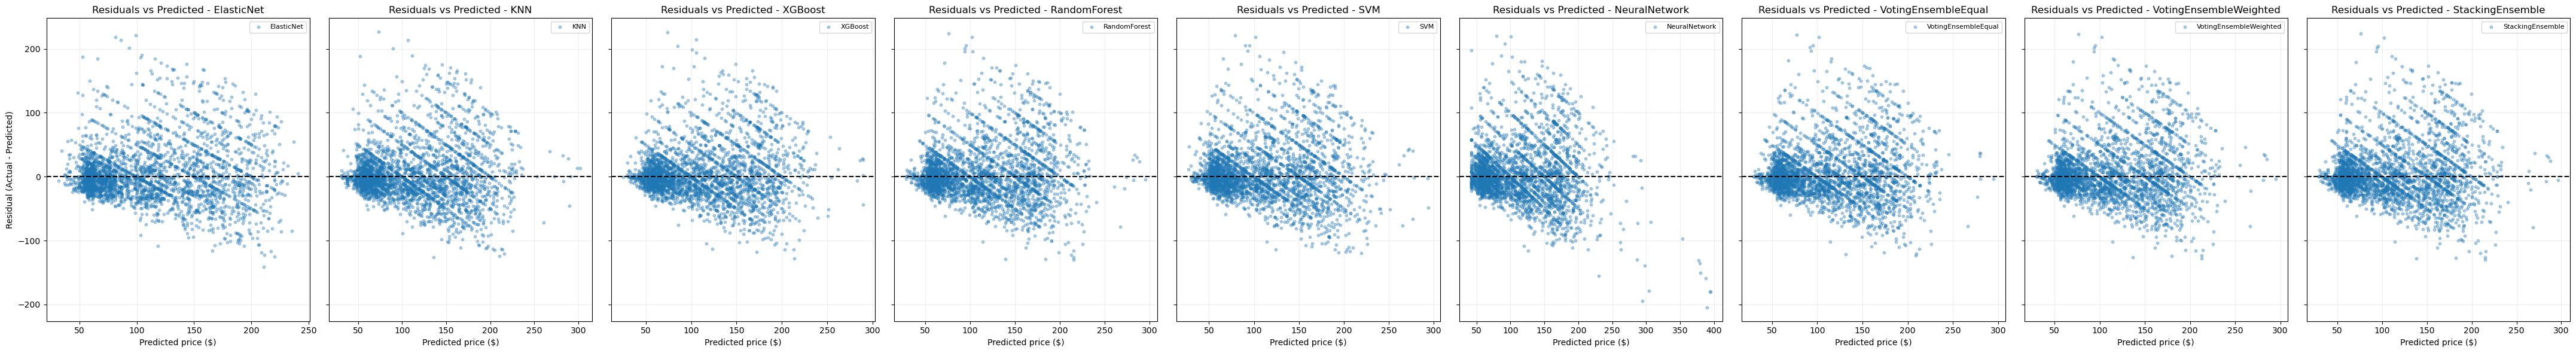

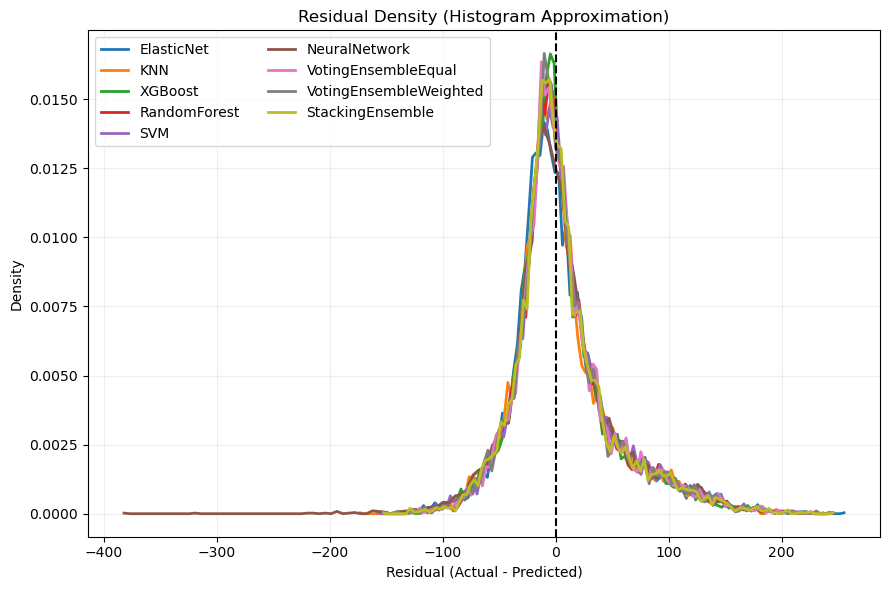

In [13]:
# Core diagnostic plots.
identity_min = float(min(y_true_dollars.min(), *(values.min() for values in predictions_dollars.values())))
identity_max = float(max(y_true_dollars.max(), *(values.max() for values in predictions_dollars.values())))

model_names = list(predictions_dollars.keys())
n_models = len(model_names)
figsize_width = max(18, 4.8 * n_models)

fig_actual, axes_actual = plt.subplots(1, n_models, figsize=(figsize_width, 6), sharex=True, sharey=True)
axes_actual = np.atleast_1d(axes_actual)
for axis, model_name in zip(axes_actual, model_names):
    predicted = predictions_dollars[model_name]
    axis.scatter(y_true_dollars[scatter_indices], predicted[scatter_indices], s=10, alpha=0.35, label=model_name)
    axis.plot([identity_min, identity_max], [identity_min, identity_max], "k--", linewidth=1.5, label="y = x")
    axis.set_title(f"Actual vs Predicted - {model_name}")
    axis.set_xlabel("Actual price ($)")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
axes_actual[0].set_ylabel("Predicted price ($)")
fig_actual.tight_layout()
if SAVE_PLOTS:
    fig_actual.savefig(plot_dir / "actual_vs_predicted_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

fig_residual, axes_residual = plt.subplots(1, n_models, figsize=(figsize_width, 6), sharey=True)
axes_residual = np.atleast_1d(axes_residual)
for axis, model_name in zip(axes_residual, model_names):
    predicted = predictions_dollars[model_name]
    axis.scatter(predicted[scatter_indices], residuals[model_name][scatter_indices], s=10, alpha=0.35, label=model_name)
    axis.axhline(0.0, color="black", linestyle="--", linewidth=1.5)
    axis.set_title(f"Residuals vs Predicted - {model_name}")
    axis.set_xlabel("Predicted price ($)")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
axes_residual[0].set_ylabel("Residual (Actual - Predicted)")
fig_residual.tight_layout()
if SAVE_PLOTS:
    fig_residual.savefig(plot_dir / "residuals_vs_predicted_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

fig_kde, axis_kde = plt.subplots(1, 1, figsize=(9, 6))
for model_name, model_residuals in residuals.items():
    hist, bins = np.histogram(model_residuals, bins=120, density=True)
    centers = 0.5 * (bins[1:] + bins[:-1])
    axis_kde.plot(centers, hist, linewidth=2.0, label=model_name)
axis_kde.axvline(0.0, color="black", linestyle="--", linewidth=1.5)
axis_kde.set_title("Residual Density (Histogram Approximation)")
axis_kde.set_xlabel("Residual (Actual - Predicted)")
axis_kde.set_ylabel("Density")
axis_kde.grid(alpha=0.2)
axis_kde.legend(ncols=2)
fig_kde.tight_layout()
if SAVE_PLOTS:
    fig_kde.savefig(plot_dir / "residual_density_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## Targeted Error Diagnostics

These tables break the best model's residuals into business-relevant segments. The goal is to expose where aggregate RMSE is hiding systematic misses, especially price compression at the high end.

In [14]:
# Segment the best model's residuals to find where RMSE is concentrated.
best_model_name = str(table.sort_values("test_rmse_dollars").iloc[0]["model"])
best_predictions = predictions_dollars[best_model_name]
segment_frame = data.X_test.copy()
segment_frame["actual_price"] = y_true_dollars
segment_frame["predicted_price"] = best_predictions
segment_frame["residual"] = segment_frame["actual_price"] - segment_frame["predicted_price"]
segment_frame["absolute_error"] = segment_frame["residual"].abs()
segment_frame["predicted_to_actual_ratio"] = segment_frame["predicted_price"] / segment_frame["actual_price"].clip(lower=1.0)

if "availability_bucket" not in segment_frame:
    segment_frame["availability_bucket"] = pd.cut(
        segment_frame["availability_365"],
        bins=[-1, 0, 30, 180, 365],
        labels=["unavailable", "low", "seasonal", "high"],
    ).astype(str)
if "minimum_nights_bucket" not in segment_frame:
    segment_frame["minimum_nights_bucket"] = pd.cut(
        segment_frame["minimum_nights"],
        bins=[0, 1, 3, 7, 30, np.inf],
        labels=["one_night", "two_to_three", "four_to_seven", "eight_to_thirty", "over_thirty"],
    ).astype(str)
if "host_listing_count_bucket" not in segment_frame:
    segment_frame["host_listing_count_bucket"] = pd.cut(
        segment_frame["calculated_host_listings_count"],
        bins=[0, 1, 5, 20, np.inf],
        labels=["single_listing", "small_portfolio", "medium_portfolio", "large_portfolio"],
    ).astype(str)

segment_frame["actual_price_band"] = pd.qcut(segment_frame["actual_price"], q=5, duplicates="drop")


def summarize_segment(column_name: str, min_rows: int = 30) -> pd.DataFrame:
    summary = (
        segment_frame.groupby(column_name, observed=True)
        .agg(
            rows=("absolute_error", "size"),
            actual_median=("actual_price", "median"),
            predicted_median=("predicted_price", "median"),
            mae=("absolute_error", "mean"),
            rmse=("residual", lambda values: float(np.sqrt(np.mean(np.square(values))))),
            bias=("residual", "mean"),
            prediction_ratio=("predicted_to_actual_ratio", "median"),
        )
        .query("rows >= @min_rows")
        .sort_values("rmse", ascending=False)
    )
    return summary.round(3)

print(f"Best model for segmented diagnostics: {best_model_name}")
print("\nBy actual price band")
display(summarize_segment("actual_price_band", min_rows=1))
print("\nBy room type")
display(summarize_segment("room_type", min_rows=1))
print("\nBy borough")
display(summarize_segment("neighbourhood_group", min_rows=1))
print("\nBy minimum-night band")
display(summarize_segment("minimum_nights_bucket", min_rows=1))
print("\nBy availability band")
display(summarize_segment("availability_bucket", min_rows=1))
print("\nBy host portfolio size")
display(summarize_segment("host_listing_count_bucket", min_rows=1))
print("\nHighest-error neighborhoods with at least 80 test rows")
display(summarize_segment("neighbourhood", min_rows=80).head(15))

Best model for segmented diagnostics: XGBoost

By actual price band


,rows,actual_median,predicted_median,mae,rmse,bias,prediction_ratio
actual_price_band,,,,,,,
"(175.0, 333.0]",1810,225.0,173.988,62.659,77.275,59.803,0.752
"(124.0, 175.0]",1857,150.0,146.091,27.680,34.783,4.002,0.986
"(89.0, 124.0]",1789,100.0,111.253,26.622,33.935,-9.688,1.071
"(60.0, 89.0]",1759,75.0,77.255,19.089,27.059,-8.790,1.052
"(9.999, 60.0]",1961,50.0,58.574,15.833,22.649,-14.438,1.243



By room type


,rows,actual_median,predicted_median,mae,rmse,bias,prediction_ratio
room_type,,,,,,,
Entire home/apt,4662,150.0,152.490,39.754,52.295,7.583,1.004
Shared room,233,49.0,48.230,21.128,40.184,9.224,1.021
Private room,4281,70.0,68.495,20.279,31.632,3.986,1.030



By borough


...

,rows,actual_median,predicted_median,mae,rmse,bias,prediction_ratio
availability_bucket,,,,,,,
unavailable,3357,100.0,102.995,30.433,43.813,5.891,1.017
high,2587,105.0,114.409,29.661,43.802,6.389,1.018
seasonal,2196,100.0,104.467,30.664,43.801,6.476,1.012
low,1036,104.5,115.288,29.762,41.551,3.901,1.032



By host portfolio size


,rows,actual_median,predicted_median,mae,rmse,bias,prediction_ratio
host_listing_count_bucket,,,,,,,
single_listing,6055,110.0,116.770,32.955,46.191,6.377,1.017
small_portfolio,2277,85.0,82.310,26.055,39.152,5.371,1.015
medium_portfolio,487,70.0,71.062,20.469,35.151,4.741,1.032
large_portfolio,357,175.0,172.000,23.057,33.386,3.974,1.011



Highest-error neighborhoods with at least 80 test rows


,rows,actual_median,predicted_median,mae,rmse,bias,prediction_ratio
neighbourhood,,,,,,,
Midtown,236,175.0,178.992,43.503,56.903,7.593,1.002
Park Slope,93,152.0,150.811,42.191,56.310,14.488,0.959
Lower East Side,166,128.0,144.557,36.791,53.211,8.569,1.031
Chelsea,177,175.0,182.993,40.153,50.843,8.663,0.970
Murray Hill,85,175.0,171.683,37.637,50.824,16.534,0.970
Upper West Side,376,135.0,150.727,36.542,50.478,5.815,1.023
Clinton Hill,118,110.0,129.759,36.036,50.040,9.977,0.998
East Village,348,140.0,164.092,37.546,49.462,-0.456,1.043
West Village,130,189.0,191.635,37.086,47.930,6.412,0.979


,actual_price_decile,rows,actual_mean,predicted_mean,residual_mean,mae,prediction_ratio_median
0,"(9.999, 49.0]",971,39.588,56.369,-16.781,17.127,1.366
1,"(49.0, 60.0]",990,55.239,67.379,-12.140,14.564,1.133
2,"(60.0, 75.0]",1026,69.358,77.831,-8.473,16.833,1.051
3,"(75.0, 89.0]",733,82.585,91.818,-9.233,22.248,1.056
4,"(89.0, 100.0]",1045,96.580,105.900,-9.320,25.955,1.055
5,"(100.0, 124.0]",744,113.853,124.058,-10.205,27.559,1.081
6,"(124.0, 150.0]",1269,139.686,139.665,0.022,27.566,1.014
7,"(150.0, 175.0]",588,166.473,153.882,12.591,27.926,0.938
8,"(175.0, 220.0]",900,196.403,163.601,32.802,38.168,0.857
9,"(220.0, 333.0]",910,263.460,176.954,86.507,86.880,0.679


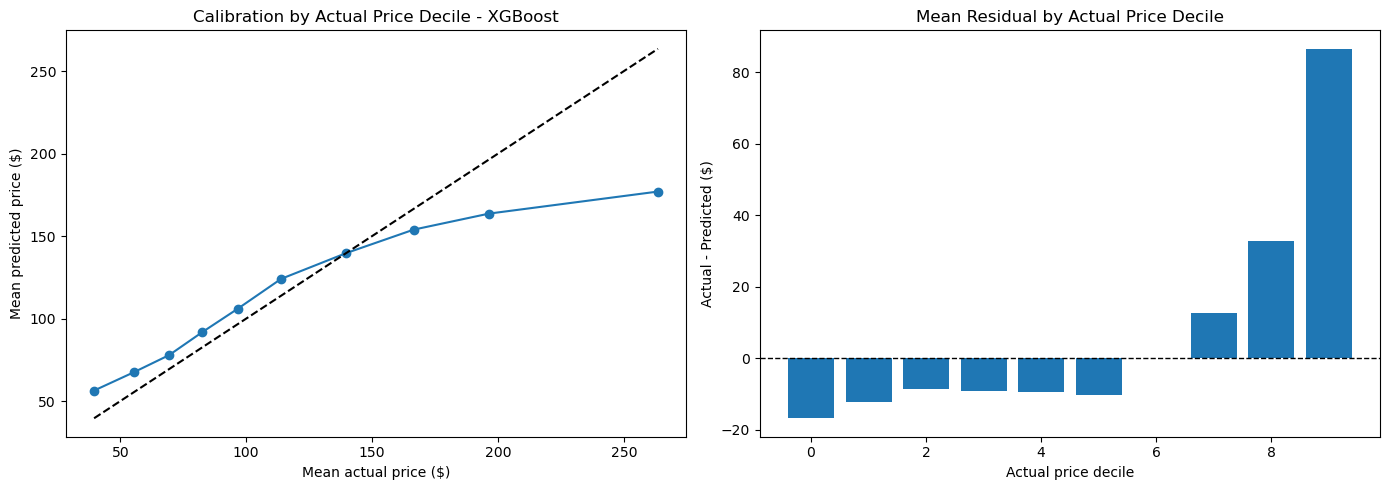

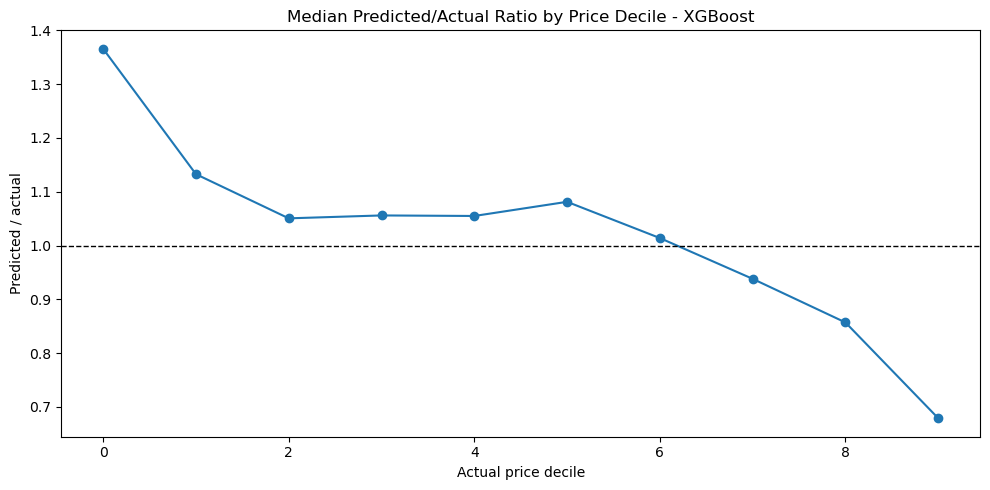

In [15]:
# Calibration and bias checks show whether predictions compress toward the middle.
calibration_frame = segment_frame.copy()
calibration_frame["actual_price_decile"] = pd.qcut(
    calibration_frame["actual_price"],
    q=10,
    duplicates="drop",
)
calibration_summary = (
    calibration_frame.groupby("actual_price_decile", observed=True)
    .agg(
        rows=("absolute_error", "size"),
        actual_mean=("actual_price", "mean"),
        predicted_mean=("predicted_price", "mean"),
        residual_mean=("residual", "mean"),
        mae=("absolute_error", "mean"),
        prediction_ratio_median=("predicted_to_actual_ratio", "median"),
    )
    .reset_index()
)
display(calibration_summary.round(3))

fig_calibration, axes_calibration = plt.subplots(1, 2, figsize=(14, 5))
axes_calibration[0].plot(calibration_summary["actual_mean"], calibration_summary["predicted_mean"], marker="o")
calibration_min = float(min(calibration_summary["actual_mean"].min(), calibration_summary["predicted_mean"].min()))
calibration_max = float(max(calibration_summary["actual_mean"].max(), calibration_summary["predicted_mean"].max()))
axes_calibration[0].plot([calibration_min, calibration_max], [calibration_min, calibration_max], "--", color="black")
axes_calibration[0].set_title(f"Calibration by Actual Price Decile - {best_model_name}")
axes_calibration[0].set_xlabel("Mean actual price ($)")
axes_calibration[0].set_ylabel("Mean predicted price ($)")
axes_calibration[1].bar(range(len(calibration_summary)), calibration_summary["residual_mean"])
axes_calibration[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes_calibration[1].set_title("Mean Residual by Actual Price Decile")
axes_calibration[1].set_xlabel("Actual price decile")
axes_calibration[1].set_ylabel("Actual - Predicted ($)")
fig_calibration.tight_layout()
if SAVE_PLOTS:
    fig_calibration.savefig(plot_dir / "calibration_and_bias_by_price_decile.png", dpi=150, bbox_inches="tight")
plt.show()

fig_ratio, axis_ratio = plt.subplots(1, 1, figsize=(10, 5))
axis_ratio.plot(calibration_summary.index, calibration_summary["prediction_ratio_median"], marker="o")
axis_ratio.axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axis_ratio.set_title(f"Median Predicted/Actual Ratio by Price Decile - {best_model_name}")
axis_ratio.set_xlabel("Actual price decile")
axis_ratio.set_ylabel("Predicted / actual")
fig_ratio.tight_layout()
if SAVE_PLOTS:
    fig_ratio.savefig(plot_dir / "predicted_to_actual_ratio_by_price_decile.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Engineering Audit

The shared preprocessing now includes listing-level features that can be built without peeking at test targets. The target-mean features are fitted inside each sklearn pipeline, so cross-validation folds only learn category priors from their own training fold.

In [16]:
# Show the engineered feature groups available for the next retraining run.
import importlib
import pricing_lab.data as pricing_data

pricing_data = importlib.reload(pricing_data)
feature_audit = pd.DataFrame(
    [
        {"feature_group": "one_hot_categorical", "feature": feature_name}
        for feature_name in pricing_data.CATEGORICAL_FEATURES
    ]
    + [
        {"feature_group": "target_mean_encoded", "feature": feature_name}
        for feature_name in pricing_data.TARGET_ENCODED_FEATURES
    ]
    + [
        {"feature_group": "numeric", "feature": feature_name}
        for feature_name in pricing_data.NUMERIC_FEATURES
    ]
)
display(feature_audit)

required_feature_columns = (
    pricing_data.CATEGORICAL_FEATURES + pricing_data.NUMERIC_FEATURES + pricing_data.TARGET_ENCODED_FEATURES
)
missing_feature_columns = sorted(set(required_feature_columns) - set(data.X_train.columns))
if missing_feature_columns:
    print("Rerun the data-loading cell to populate newly engineered columns:", missing_feature_columns)
else:
    print("All engineered feature columns are present in the current train/test split.")

ImportError: cannot import name 'TARGET_ENCODED_FEATURES' from 'pricing_lab.data' (/Users/Kushal/Projects/BNB_Pricing/pricing_lab/data.py)

## Price Cap Audit

The preprocessing removes high-end prices with an IQR rule before modeling. This audit quantifies what is excluded so the team can decide whether the project is modeling the clipped mainstream market or the full listing market.

In [ ]:
# Quantify the IQR price cap used by shared cleaning.
raw_frame = pd.read_csv(resolved_csv)
price_audit_frame = raw_frame.copy()
price_audit_frame["reviews_per_month"] = price_audit_frame["reviews_per_month"].fillna(0)
price_audit_frame["last_review"] = price_audit_frame["last_review"].fillna("No reviews")
price_audit_frame = price_audit_frame.dropna(subset=["name", "host_name"])
positive_price_frame = price_audit_frame[price_audit_frame["price"] > 0].copy()
first_quartile = float(positive_price_frame["price"].quantile(0.25))
third_quartile = float(positive_price_frame["price"].quantile(0.75))
interquartile_range = third_quartile - first_quartile
price_upper_bound = third_quartile + 1.5 * interquartile_range
included_frame = positive_price_frame[positive_price_frame["price"] <= price_upper_bound]
excluded_frame = positive_price_frame[positive_price_frame["price"] > price_upper_bound]

price_cap_summary = pd.DataFrame(
    [
        {
            "scope": "positive_price_rows_before_cap",
            "rows": len(positive_price_frame),
            "share": 1.0,
            "min_price": positive_price_frame["price"].min(),
            "median_price": positive_price_frame["price"].median(),
            "mean_price": positive_price_frame["price"].mean(),
            "max_price": positive_price_frame["price"].max(),
        },
        {
            "scope": "included_after_iqr_cap",
            "rows": len(included_frame),
            "share": len(included_frame) / len(positive_price_frame),
            "min_price": included_frame["price"].min(),
            "median_price": included_frame["price"].median(),
            "mean_price": included_frame["price"].mean(),
            "max_price": included_frame["price"].max(),
        },
        {
            "scope": "excluded_above_iqr_cap",
            "rows": len(excluded_frame),
            "share": len(excluded_frame) / len(positive_price_frame),
            "min_price": excluded_frame["price"].min() if len(excluded_frame) else np.nan,
            "median_price": excluded_frame["price"].median() if len(excluded_frame) else np.nan,
            "mean_price": excluded_frame["price"].mean() if len(excluded_frame) else np.nan,
            "max_price": excluded_frame["price"].max() if len(excluded_frame) else np.nan,
        },
    ]
)
print(f"IQR price upper bound used for modeling: ${price_upper_bound:,.2f}")
display(price_cap_summary.round(3))

if len(excluded_frame):
    excluded_by_segment = (
        excluded_frame.groupby(["neighbourhood_group", "room_type"], observed=True)
        .agg(rows=("price", "size"), median_price=("price", "median"), mean_price=("price", "mean"))
        .sort_values("rows", ascending=False)
        .head(15)
    )
    display(excluded_by_segment.round(2))

## Artifact Environment Check

Loaded model artifacts should be treated as reproducible only when the runtime package versions match the environment that produced them. This check records the active versions and points out when retraining is safer than comparing stale artifacts.

In [ ]:
# Capture runtime versions next to artifact timestamps for reproducibility checks.
import platform
import sklearn
import xgboost

artifact_rows = []
for artifact_path in sorted(model_output_path.glob("*.joblib")):
    artifact_rows.append(
        {
            "artifact": artifact_path.name,
            "modified_at": pd.Timestamp(artifact_path.stat().st_mtime, unit="s"),
            "size_mb": artifact_path.stat().st_size / 1_000_000,
        }
    )

runtime_versions = pd.DataFrame(
    [
        {"package": "python", "version": platform.python_version()},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "xgboost", "version": xgboost.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
    ]
)

display(runtime_versions)
display(pd.DataFrame(artifact_rows).round({"size_mb": 3}))
print(
    "If artifact loading emits InconsistentVersionWarning, rebuild models in this environment "
    "before treating RMSE/R2 deltas as final."
)

Skipping permutation importance (RUN_PERMUTATION=False).


/opt/homebrew/Caskroom/miniforge/base/envs/ml-optimized/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


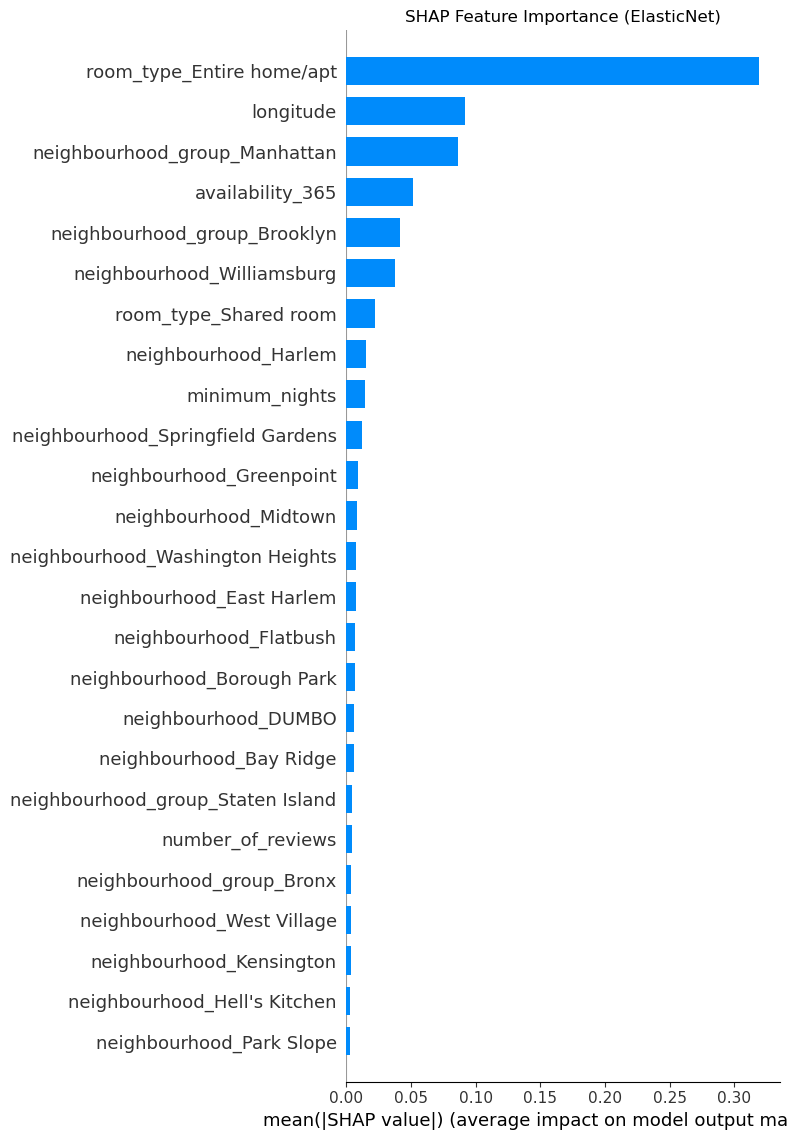

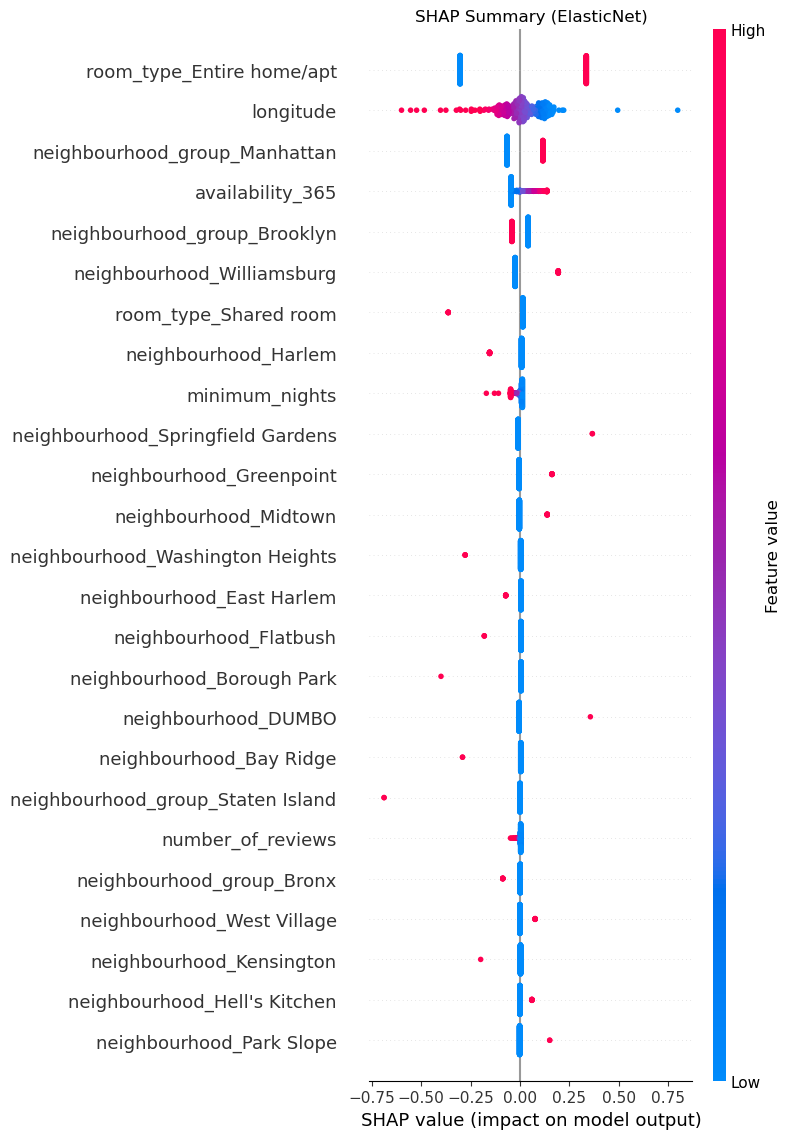

,feature,mean_abs_shap
222,room_type_Entire home/apt,0.319460
226,longitude,0.091641
2,neighbourhood_group_Manhattan,0.086615
231,availability_365,0.051639
1,neighbourhood_group_Brooklyn,0.041285
216,neighbourhood_Williamsburg,0.037517
224,room_type_Shared room,0.022317
98,neighbourhood_Harlem,0.015416
227,minimum_nights,0.014260
185,neighbourhood_Springfield Gardens,0.011772


Wrote /Users/Kushal/Projects/BNB_Pricing/artifacts/shap_feature_importance_elasticnet.csv


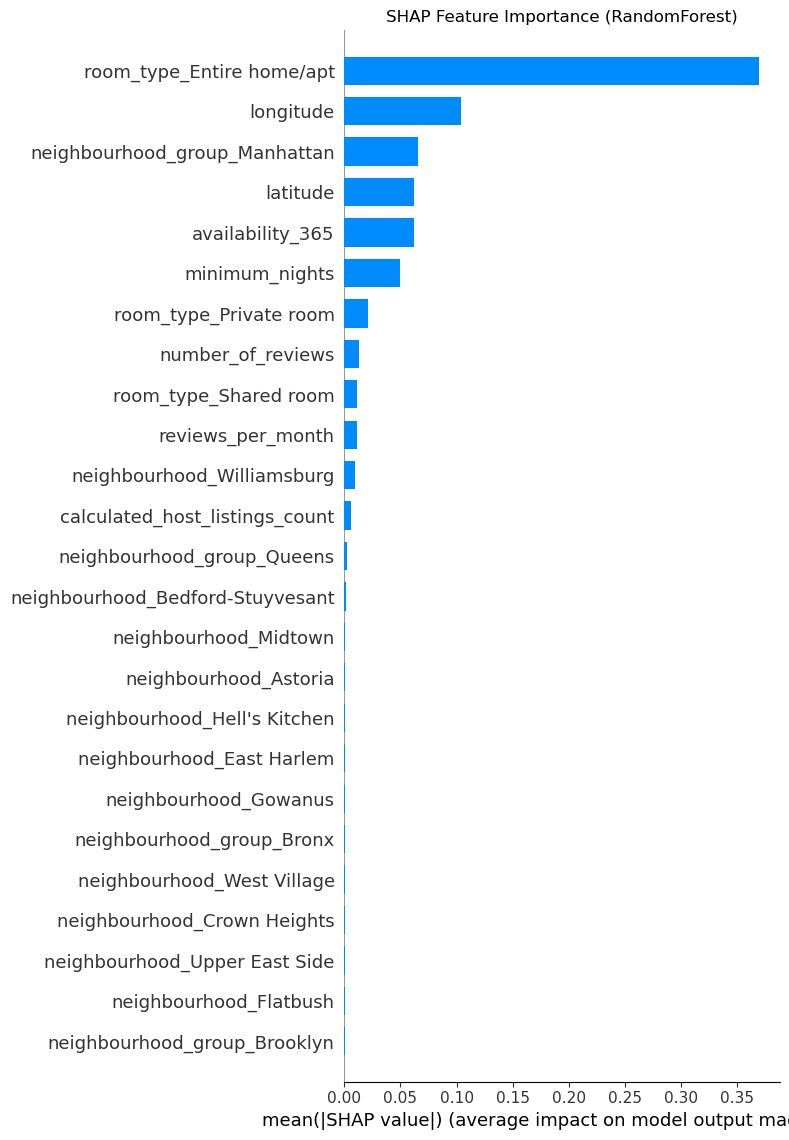

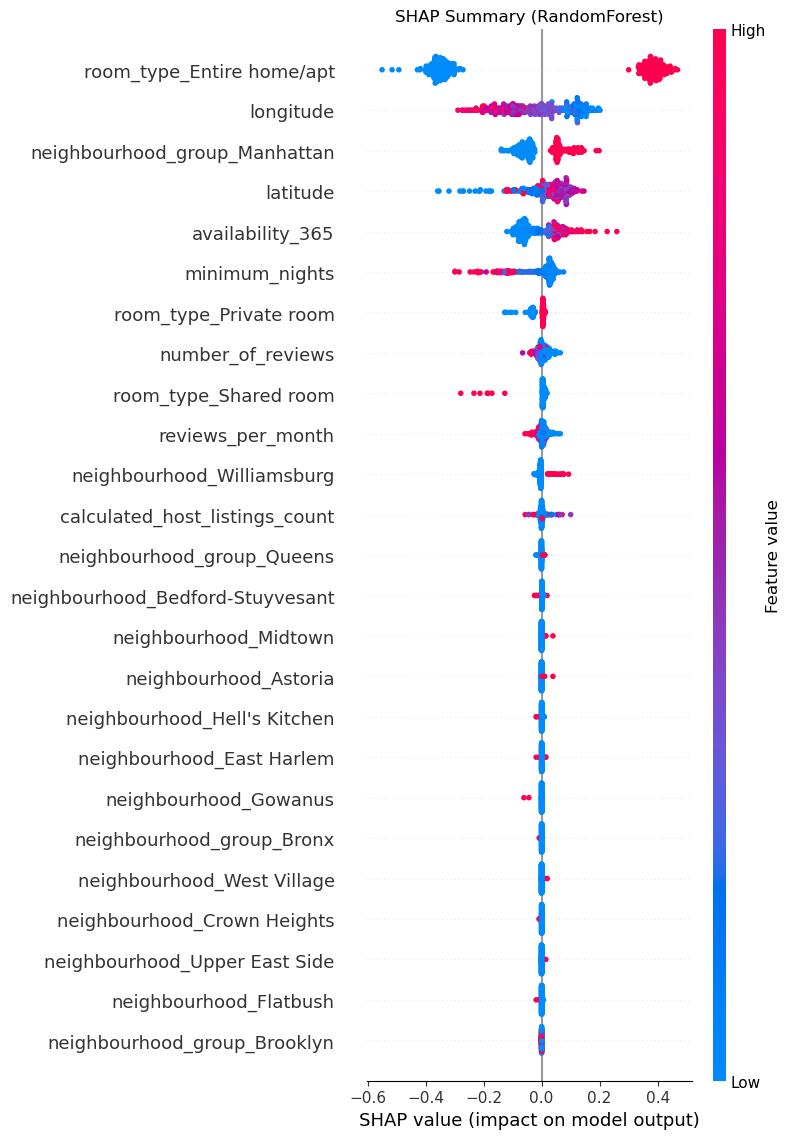

,feature,mean_abs_shap
208,room_type_Entire home/apt,0.369616
212,longitude,0.104266
2,neighbourhood_group_Manhattan,0.065647
211,latitude,0.061900
217,availability_365,0.061873
213,minimum_nights,0.049617
209,room_type_Private room,0.021182
214,number_of_reviews,0.013429
210,room_type_Shared room,0.011112
215,reviews_per_month,0.010831


Wrote /Users/Kushal/Projects/BNB_Pricing/artifacts/shap_feature_importance_randomforest.csv


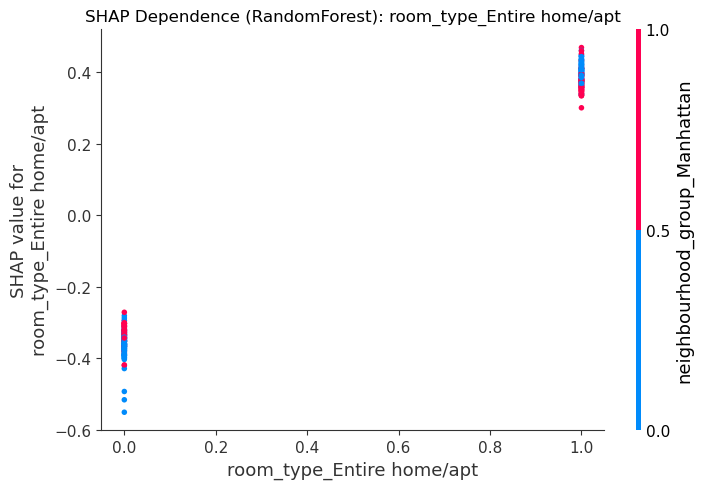

XGBoost explainer fallback (could not convert string to float: '[4.636797E0]'); using model-agnostic SHAP Explainer.


PermutationExplainer explainer: 301it [00:20,  8.51it/s]                         
/var/folders/31/_t7r4pl15ng3lrdcglpq152w0000gr/T/ipykernel_48711/3625473118.py:85: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_array, transformed_df, plot_type="bar", max_display=25, show=False)


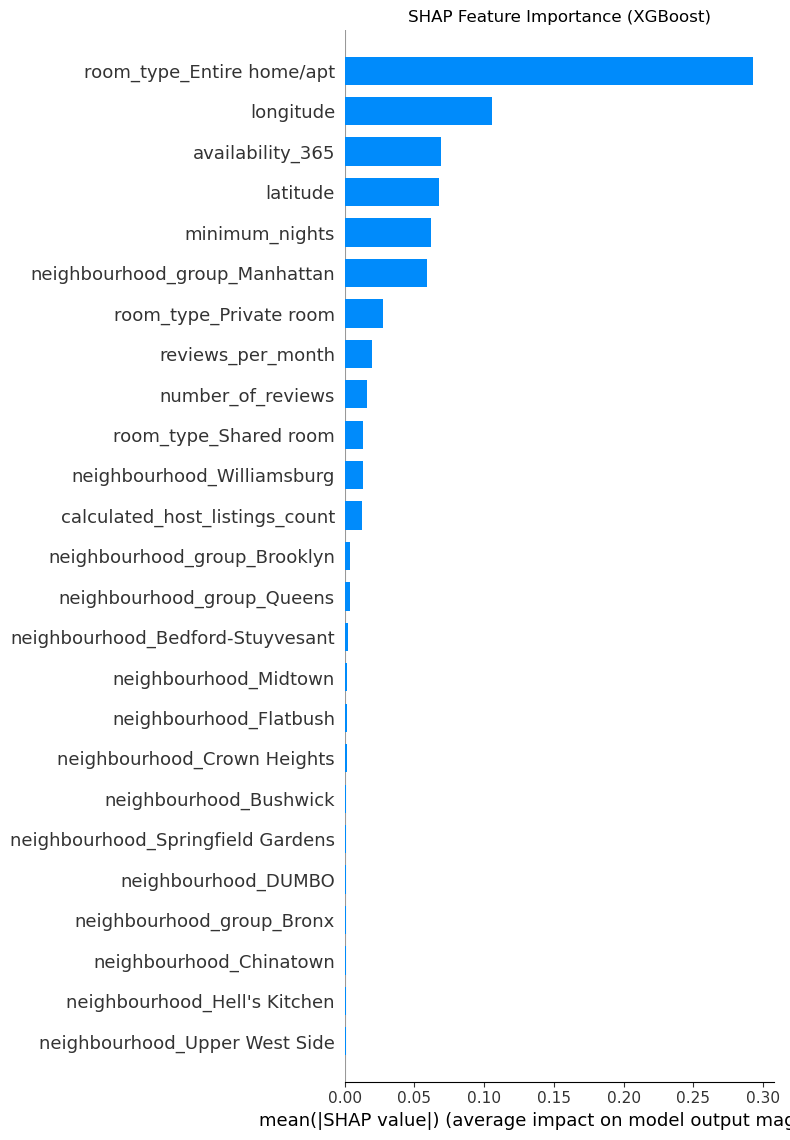

/var/folders/31/_t7r4pl15ng3lrdcglpq152w0000gr/T/ipykernel_48711/3625473118.py:92: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_array, transformed_df, max_display=25, show=False)


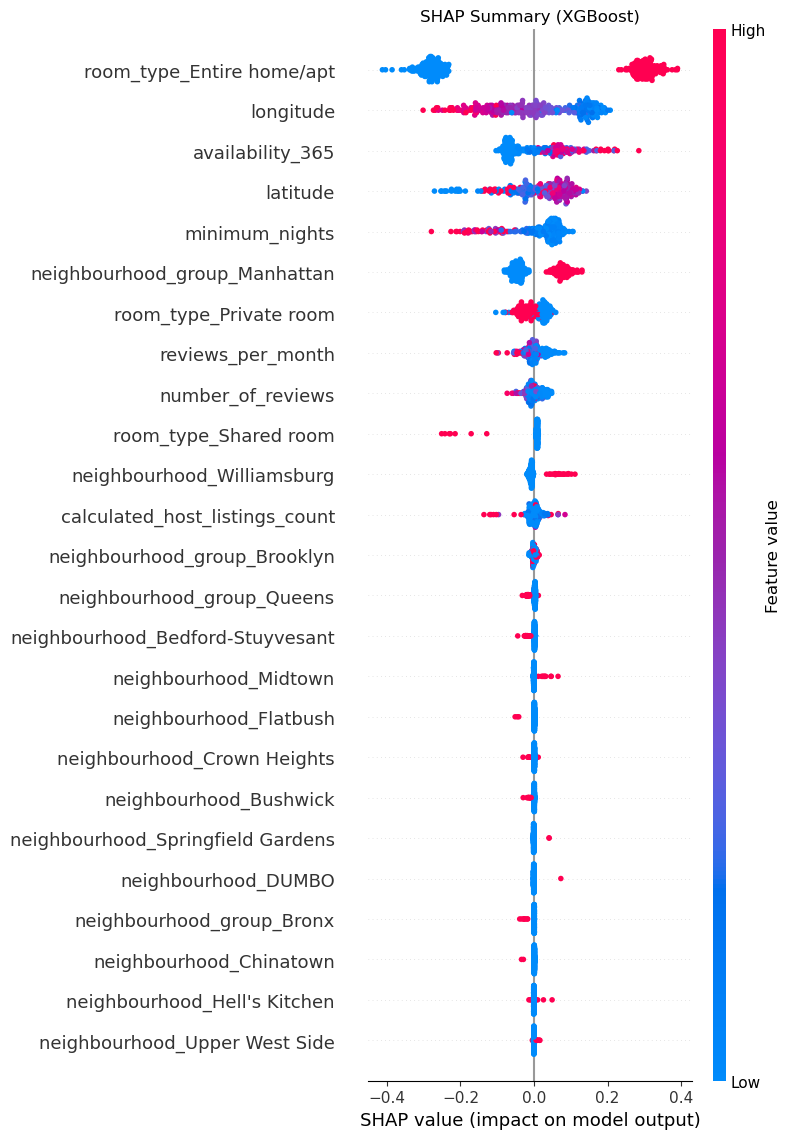

,feature,mean_abs_shap
222,room_type_Entire home/apt,0.293036
226,longitude,0.105454
231,availability_365,0.069186
225,latitude,0.067687
227,minimum_nights,0.061751
2,neighbourhood_group_Manhattan,0.059173
223,room_type_Private room,0.027124
229,reviews_per_month,0.019568
228,number_of_reviews,0.016055
224,room_type_Shared room,0.013248


Wrote /Users/Kushal/Projects/BNB_Pricing/artifacts/shap_feature_importance_xgboost.csv


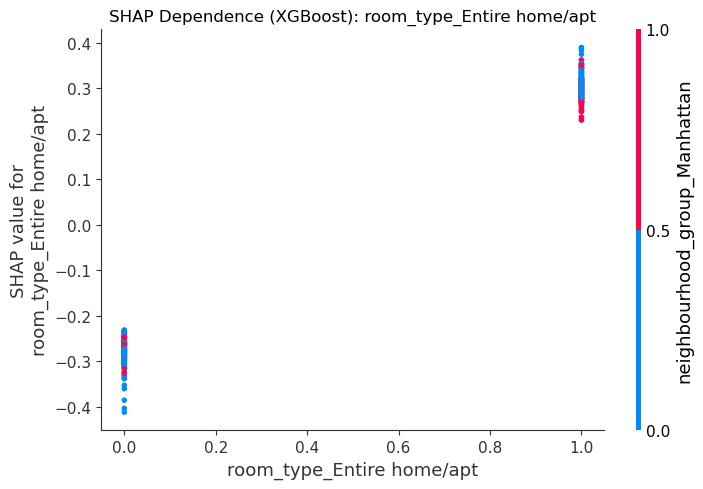

In [ ]:
# Feature importance: permutation plus allowlisted SHAP.
raw_feature_names = list(data.X_test.columns)
y_true_log_for_importance = data.y_test.to_numpy(dtype=np.float64)
permutation_df = pd.DataFrame(columns=["model", "feature", "importance_mean", "importance_std"])

if RUN_PERMUTATION:
    permutation_rows: list[dict[str, Any]] = []
    for model_name, model_pipeline in model_pipelines.items():
        perm = permutation_importance(
            model_pipeline,
            data.X_test,
            y_true_log_for_importance,
            scoring="neg_root_mean_squared_error",
            n_repeats=PERMUTATION_REPEATS,
            random_state=config.RANDOM_STATE,
            n_jobs=1,
        )
        for feature_name, mean_value, std_value in zip(raw_feature_names, perm.importances_mean, perm.importances_std):
            permutation_rows.append(
                {
                    "model": model_name,
                    "feature": feature_name,
                    "importance_mean": float(mean_value),
                    "importance_std": float(std_value),
                }
            )

    permutation_df = pd.DataFrame(permutation_rows).sort_values(["model", "importance_mean"], ascending=[True, False])
    display(permutation_df.groupby("model").head(TOP_FEATURE_COUNT))

    perm_csv_path = PROJECT_ROOT / "artifacts" / "permutation_importance_all_models.csv"
    perm_csv_path.parent.mkdir(parents=True, exist_ok=True)
    permutation_df.to_csv(perm_csv_path, index=False)
    print(f"Wrote {perm_csv_path}")
else:
    print("Skipping permutation importance (RUN_PERMUTATION=False).")

# SHAP is limited to models with efficient explainers.
SHAP_ENABLED_MODELS = {"XGBoost", "RandomForest", "ElasticNet"}
shap_rows = min(SHAP_SAMPLE_SIZE, len(data.X_test))
shap_input_sample = data.X_test.sample(n=shap_rows, random_state=config.RANDOM_STATE)

def to_numpy(values: Any) -> np.ndarray:
    if isinstance(values, np.ndarray):
        return values
    return np.asarray(values)


def extract_shap_matrix(pipeline: Any) -> tuple[pd.DataFrame, Any]:
    prep = pipeline.named_steps["prep"]
    transformed = prep.transform(shap_input_sample)
    feature_names = prep.get_feature_names_out()
    transformed_array = to_numpy(transformed)
    transformed_df = pd.DataFrame(transformed_array, columns=feature_names)
    if "scale" in pipeline.named_steps:
        scaler = pipeline.named_steps["scale"]
        scaled_array = to_numpy(scaler.transform(transformed_df))
        transformed_df = pd.DataFrame(scaled_array, columns=feature_names)
    return transformed_df, pipeline.named_steps["model"]


if RUN_SHAP:
    for model_name in sorted(SHAP_ENABLED_MODELS):
        if model_name not in model_pipelines:
            print(f"Skipping SHAP for {model_name}: model not present.")
            continue
        pipeline = model_pipelines[model_name]
        transformed_df, estimator = extract_shap_matrix(pipeline)
        background_rows = min(SHAP_BACKGROUND_SIZE, len(transformed_df))
        background_df = transformed_df.sample(n=background_rows, random_state=config.RANDOM_STATE)

        try:
            if model_name in {"XGBoost", "RandomForest"}:
                explainer = shap.TreeExplainer(estimator)
                shap_values = explainer.shap_values(transformed_df)
            else:
                explainer = shap.LinearExplainer(estimator, background_df)
                shap_values = explainer.shap_values(transformed_df)
        except Exception as err:
            print(f"{model_name} explainer fallback ({err}); using model-agnostic SHAP Explainer.")
            explainer = shap.Explainer(estimator.predict, background_df)
            shap_values = explainer(transformed_df).values

        shap_values_array = to_numpy(shap_values)
        shap.summary_plot(shap_values_array, transformed_df, plot_type="bar", max_display=25, show=False)
        plt.title(f"SHAP Feature Importance ({model_name})")
        plt.tight_layout()
        if SAVE_PLOTS:
            plt.savefig(plot_dir / f"shap_feature_importance_bar_{model_name.lower()}.png", dpi=150, bbox_inches="tight")
        plt.show()

        shap.summary_plot(shap_values_array, transformed_df, max_display=25, show=False)
        plt.title(f"SHAP Summary ({model_name})")
        plt.tight_layout()
        if SAVE_PLOTS:
            plt.savefig(plot_dir / f"shap_summary_beeswarm_{model_name.lower()}.png", dpi=150, bbox_inches="tight")
        plt.show()

        mean_abs_shap = np.abs(shap_values_array).mean(axis=0)
        shap_df = pd.DataFrame(
            {"feature": transformed_df.columns.to_list(), "mean_abs_shap": mean_abs_shap}
        ).sort_values("mean_abs_shap", ascending=False)
        display(shap_df.head(30))

        shap_csv_path = PROJECT_ROOT / "artifacts" / f"shap_feature_importance_{model_name.lower()}.csv"
        shap_df.to_csv(shap_csv_path, index=False)
        print(f"Wrote {shap_csv_path}")

        if model_name in {"XGBoost", "RandomForest"}:
            top_feature_name = str(shap_df.iloc[0]["feature"])
            shap.dependence_plot(top_feature_name, shap_values_array, transformed_df, show=False)
            plt.title(f"SHAP Dependence ({model_name}): {top_feature_name}")
            plt.tight_layout()
            if SAVE_PLOTS:
                plt.savefig(plot_dir / f"shap_dependence_top_feature_{model_name.lower()}.png", dpi=150, bbox_inches="tight")
            plt.show()
else:
    print("Skipping SHAP analysis (RUN_SHAP=False).")

# Non-SHAP models use permutation importance only.
if RUN_PERMUTATION:
    non_shap_models = sorted([name for name in model_pipelines if name not in SHAP_ENABLED_MODELS])
    non_shap_permutation_df = permutation_df[permutation_df["model"].isin(non_shap_models)].copy()
    non_shap_positive_df = non_shap_permutation_df[non_shap_permutation_df["importance_mean"] > 0.0].copy()
    non_shap_ranked_df = non_shap_positive_df.sort_values(["model", "importance_mean"], ascending=[True, False])

    if non_shap_ranked_df.empty:
        print("No positive permutation importances for non-SHAP models.")
    else:
        display(non_shap_ranked_df.groupby("model").head(TOP_FEATURE_COUNT))

        plot_source = non_shap_ranked_df.groupby("model").head(min(TOP_FEATURE_COUNT, 10))
        if not plot_source.empty:
            model_count = len(non_shap_models)
            figure_height = max(4.0, 3.0 * model_count)
            fig, axes = plt.subplots(model_count, 1, figsize=(12, figure_height), squeeze=False)
            for axis, model_name in zip(axes.flatten(), non_shap_models):
                model_slice = plot_source[plot_source["model"] == model_name].sort_values("importance_mean", ascending=True)
                if model_slice.empty:
                    axis.set_title(f"Permutation Importance ({model_name})")
                    axis.text(0.5, 0.5, "No positive features", ha="center", va="center")
                    axis.set_axis_off()
                    continue
                axis.barh(model_slice["feature"], model_slice["importance_mean"], xerr=model_slice["importance_std"], alpha=0.85)
                axis.set_title(f"Permutation Importance ({model_name})")
                axis.set_xlabel("Mean RMSE increase (log scale)")
            fig.tight_layout()
            if SAVE_PLOTS:
                fig.savefig(plot_dir / "permutation_importance_non_shap_models.png", dpi=150, bbox_inches="tight")
            plt.show()

## Interpreting Importance

SHAP explains `XGBoost`, `RandomForest`, and `ElasticNet`. Other models use permutation importance; prefer features with positive mean impact and low standard deviation.


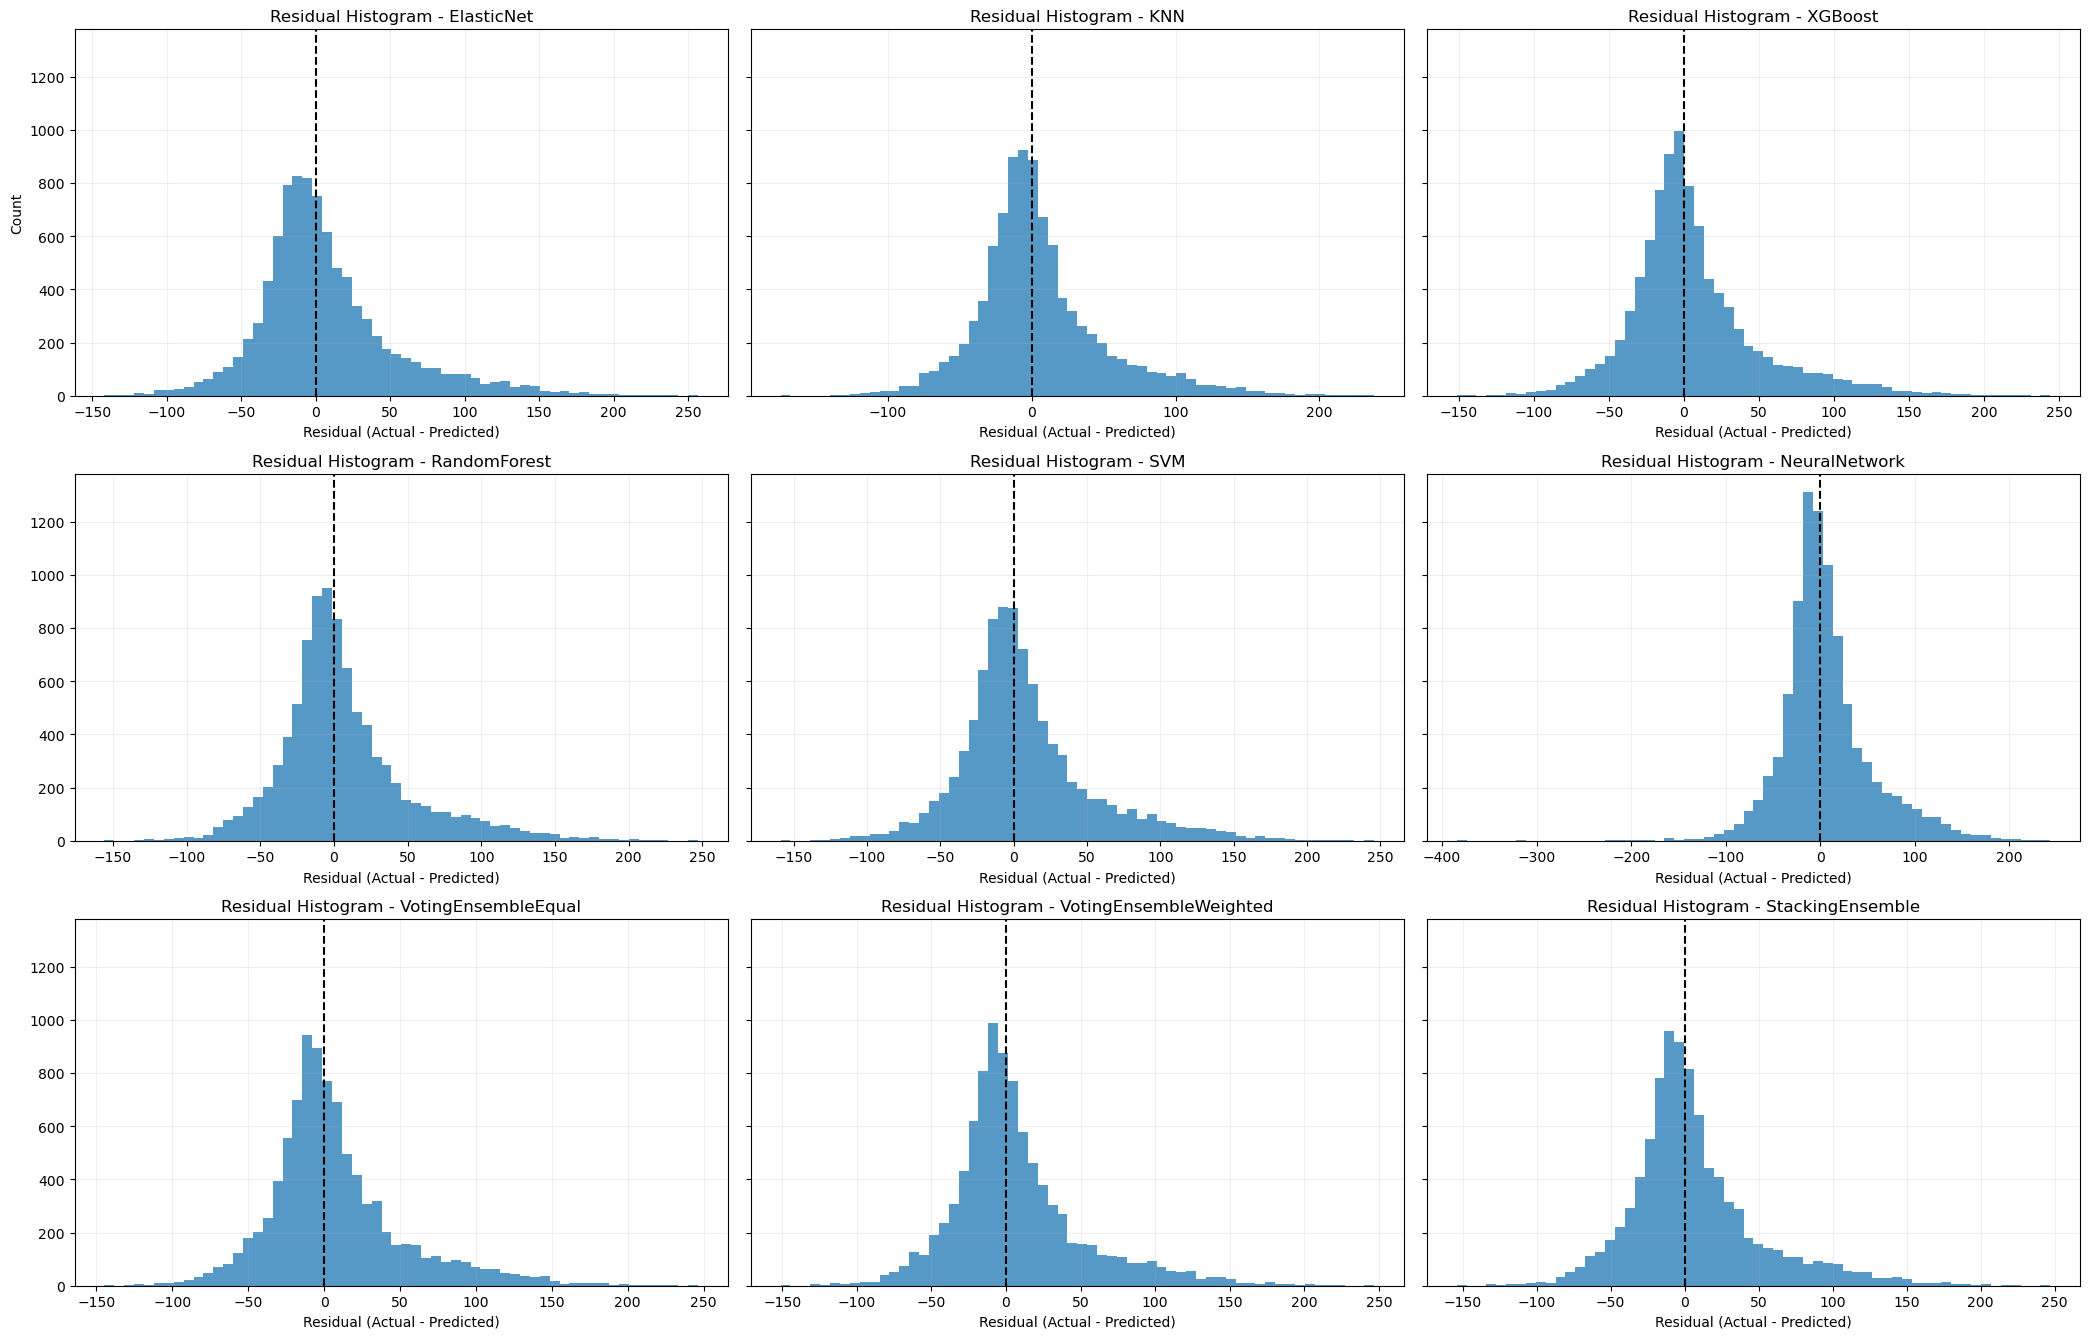

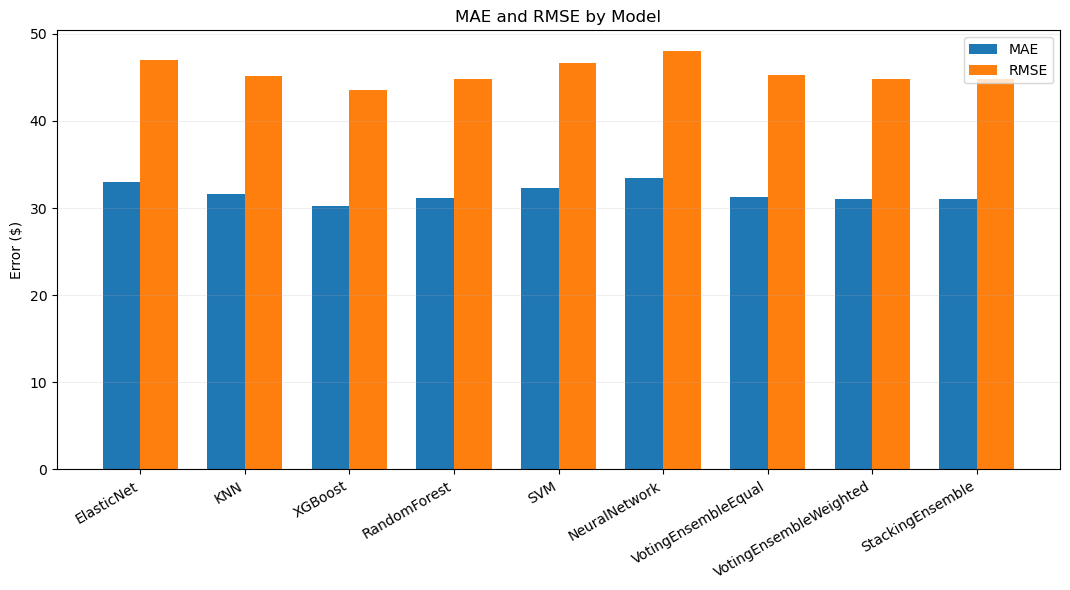

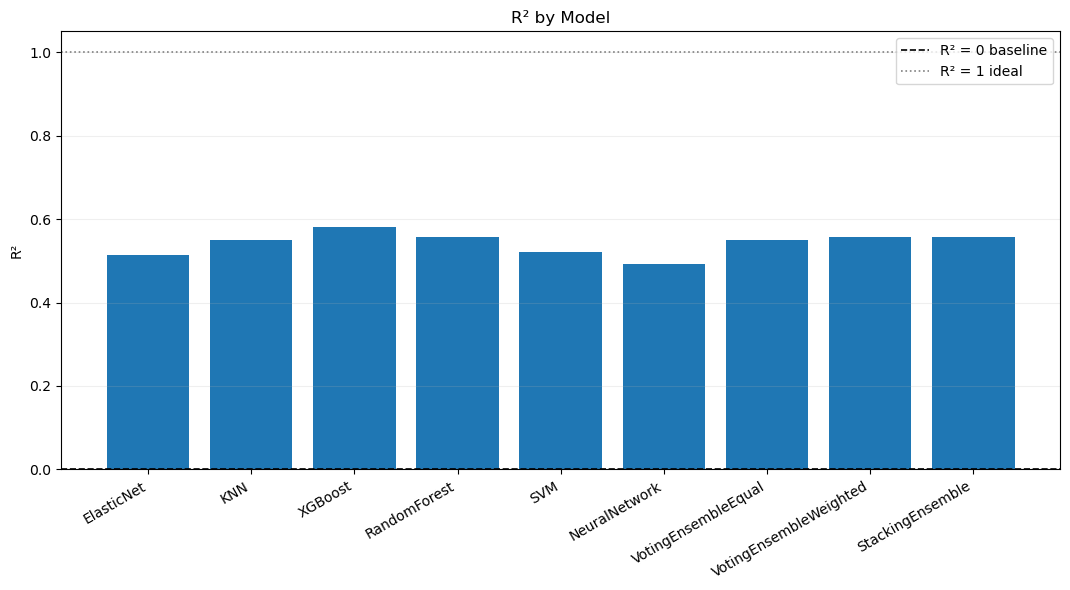

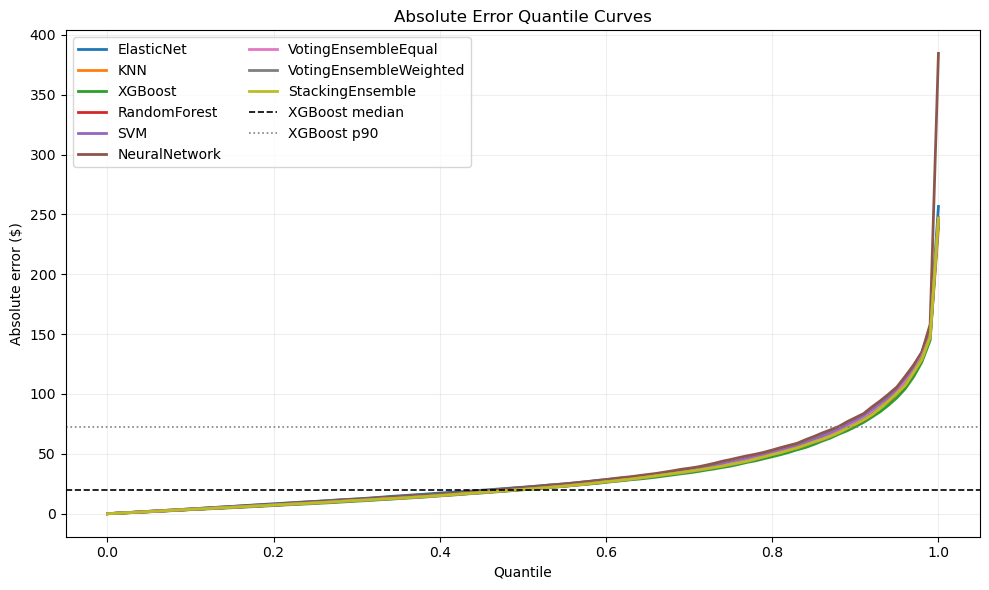

In [ ]:
# Extra model-comparison graphs
model_names = list(predictions_dollars.keys())
metrics_for_plot = table.set_index("model")

# Residual histograms per model (adaptive grid)
n_models = len(model_names)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols))
fig_hist, axes_hist = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows), sharey=True)
axes_flat = np.asarray(axes_hist).reshape(-1)
for idx, model_name in enumerate(model_names):
    axis = axes_flat[idx]
    axis.hist(residuals[model_name], bins=60, alpha=0.75)
    axis.axvline(0.0, color="black", linestyle="--", linewidth=1.5)
    axis.set_title(f"Residual Histogram - {model_name}")
    axis.set_xlabel("Residual (Actual - Predicted)")
    axis.grid(alpha=0.2)
for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].axis("off")
axes_flat[0].set_ylabel("Count")
fig_hist.tight_layout()
if SAVE_PLOTS:
    fig_hist.savefig(plot_dir / "residual_histograms_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

# MAE/RMSE grouped bar chart
x_positions = np.arange(len(model_names))
bar_width = 0.36
fig_err, axis_err = plt.subplots(1, 1, figsize=(max(9, 1.2 * len(model_names)), 6))
mae_values = [float(metrics_for_plot.loc[name, "test_mae_dollars"]) for name in model_names]
rmse_values = [float(metrics_for_plot.loc[name, "test_rmse_dollars"]) for name in model_names]
axis_err.bar(x_positions - bar_width / 2.0, mae_values, bar_width, label="MAE")
axis_err.bar(x_positions + bar_width / 2.0, rmse_values, bar_width, label="RMSE")
axis_err.set_xticks(x_positions)
axis_err.set_xticklabels(model_names, rotation=30, ha="right")
axis_err.set_ylabel("Error ($)")
axis_err.set_title("MAE and RMSE by Model")
axis_err.grid(axis="y", alpha=0.2)
axis_err.legend()
fig_err.tight_layout()
if SAVE_PLOTS:
    fig_err.savefig(plot_dir / "mae_rmse_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# R² bar chart
fig_r2, axis_r2 = plt.subplots(1, 1, figsize=(max(9, 1.2 * len(model_names)), 6))
r2_values = [float(metrics_for_plot.loc[name, "test_r2"]) for name in model_names]
r2_positions = np.arange(len(model_names))
axis_r2.bar(r2_positions, r2_values)
axis_r2.set_xticks(r2_positions)
axis_r2.set_xticklabels(model_names, rotation=30, ha="right")
axis_r2.axhline(0.0, color="black", linestyle="--", linewidth=1.2, label="R² = 0 baseline")
axis_r2.axhline(1.0, color="gray", linestyle=":", linewidth=1.2, label="R² = 1 ideal")
axis_r2.set_ylabel("R²")
axis_r2.set_title("R² by Model")
axis_r2.grid(axis="y", alpha=0.2)
axis_r2.legend()
fig_r2.tight_layout()
if SAVE_PLOTS:
    fig_r2.savefig(plot_dir / "r2_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# Absolute-error quantile curves
quantile_grid = np.linspace(0.0, 1.0, 101)
fig_quantile, axis_quantile = plt.subplots(1, 1, figsize=(10, 6))
for model_name in model_names:
    quantile_values = np.quantile(absolute_errors[model_name], quantile_grid)
    axis_quantile.plot(quantile_grid, quantile_values, linewidth=2.0, label=model_name)

best_model_name = min(model_names, key=lambda model_name: float(metrics_for_plot.loc[model_name, "test_rmse_dollars"]))
best_q50 = float(np.quantile(absolute_errors[best_model_name], 0.5))
best_q90 = float(np.quantile(absolute_errors[best_model_name], 0.9))
axis_quantile.axhline(best_q50, color="black", linestyle="--", linewidth=1.2, label=f"{best_model_name} median")
axis_quantile.axhline(best_q90, color="gray", linestyle=":", linewidth=1.2, label=f"{best_model_name} p90")
axis_quantile.set_title("Absolute Error Quantile Curves")
axis_quantile.set_xlabel("Quantile")
axis_quantile.set_ylabel("Absolute error ($)")
axis_quantile.grid(alpha=0.2)
axis_quantile.legend(ncols=2)
fig_quantile.tight_layout()
if SAVE_PLOTS:
    fig_quantile.savefig(plot_dir / "absolute_error_quantile_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Optional export summary
if SAVE_PLOTS:
    print(f"Saved plot images to {plot_dir}")
else:
    print("SAVE_PLOTS=False -> plots shown inline only.")

print("Analysis notebook complete.")

SAVE_PLOTS=False -> plots shown inline only.
Analysis notebook complete.
